In [ ]:
# Import library
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

In [ ]:
# Data real input manual dan missing value
nilai_brix = [73.0, np.nan, 76.0, np.nan, 75.5, np.nan, 73.6, np.nan, 76.0, np.nan,
              73.5, 77.5, 72.0, 76.8, 75.6, 78.5, 80.5, 79.5, 81.5, 83.0]
gula_pereduksi = [30.01, np.nan ,np.nan, np.nan, np.nan, np.nan, 45.66, np.nan, 55.26, np.nan,
                  np.nan, 37.85, np.nan, np.nan, 61.16, np.nan, np.nan, np.nan, np.nan, np.nan] #(np.nan)

# Buat DataFrame dari data asli
df = pd.DataFrame({
    'Nilai brix': nilai_brix,
    'Gula Pereduksi': gula_pereduksi
})

# Interpolasi untuk mengisi missing values
df['Nilai brix'] = df['Nilai brix'].interpolate(method='linear')
df['Gula Pereduksi'] = df['Gula Pereduksi'].interpolate(method='linear')

In [ ]:
# --- Import Library ---
import numpy as np
import tensorflow as tf
import random
import os
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler

# --- Set Seed Global ---
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

# --- Normalisasi ---
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()
X = scaler_x.fit_transform(df[['Nilai brix']])
y = scaler_y.fit_transform(df[['Gula Pereduksi']])

# --- K-Fold ---
kf = KFold(n_splits=5, shuffle=True, random_state=seed)
mse_list = []

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
import numpy as np

# Inisialisasi variabel K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Daftar variasi epoch yang akan diuji
epoch_list = list(range(100, 1100, 100))  # [100, 200, ..., 1000]
avg_mse_results = []  # Menyimpan MSE rata-rata per epoch

# Loop untuk setiap variasi epoch
for epoch in epoch_list:
    mse_fold = []

    # Loop untuk setiap fold
    for train_idx, test_idx in kf.split(X):
        X_train_fold, X_test_fold = X[train_idx], X[test_idx]
        y_train_fold, y_test_fold = y[train_idx], y[test_idx]

        # Buat ulang model untuk setiap fold
        model = Sequential([
            tf.keras.Input(shape=(1,)),
            Dense(1, activation='linear')
        ])
        model.compile(optimizer=SGD(learning_rate=0.01), loss='mse')

        # Latih model pada data training fold
        model.fit(X_train_fold, y_train_fold, epochs=epoch, verbose=0)

        # Prediksi pada data test fold
        y_pred = model.predict(X_test_fold)
        mse = mean_squared_error(y_test_fold, y_pred)
        mse_fold.append(mse)

    # Hitung rata-rata MSE dari semua fold untuk epoch ini
    avg_mse = np.mean(mse_fold)
    avg_mse_results.append(avg_mse)
    print(f"Epoch: {epoch}, Rata-rata MSE: {avg_mse:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Epoch: 100, Rata-rata MSE: 0.0908


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Epoch: 200, Rata-rata MSE: 0.0699
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Epoch: 300, Rata-rata MSE: 0.0676
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Epoch: 400, Rata-rata MSE: 0.0734
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Epoch: 500, Rata-rata MSE: 0.1049
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

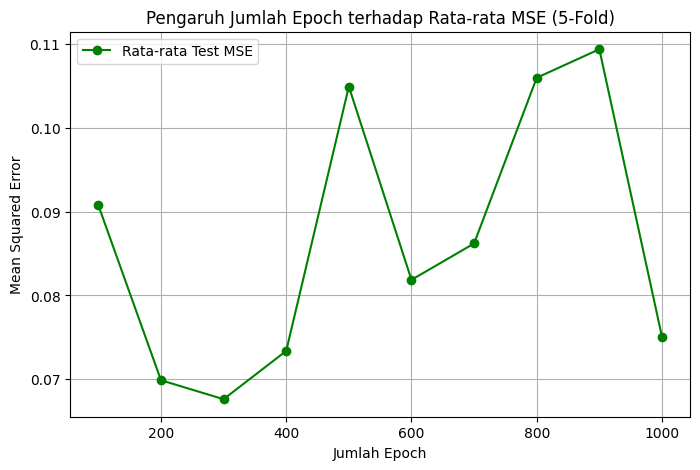

In [ ]:
#Visualisasi Jumlah Epoch terhadap Rata2 MSE
plt.figure(figsize=(8, 5))
plt.plot(epoch_list, avg_mse_results, marker='o', linestyle='-', color='green', label='Rata-rata Test MSE')
plt.title("Pengaruh Jumlah Epoch terhadap Rata-rata MSE (5-Fold)")
plt.xlabel("Jumlah Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Bangun Model JST Perceptron Lapis Tunggal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras import Input

# Arsitektur model
model = Sequential()
model.add(Input(shape=(1,)))  # Input layer
model.add(Dense(1, activation='linear'))  # Output layer (regresi)

# Kompilasi model
model.compile(optimizer=SGD(learning_rate=0.01), loss='mse')

# Latih model dengan epoch terbaik hasil uji sebelumnya
history = model.fit(X, y, epochs=300, verbose=0)

In [ ]:
# Model Training akhir menggunakan seluruh data dan epoch terbaik
history = model.fit(X, y, epochs=800, verbose=0)

# Ambil bobot dan bias dari model
weights, biases = model.layers[0].get_weights()

print(f"Bobot (Weight): {weights[0][0]:.4f}")
print(f"Bias: {biases[0]:.4f}")

Bobot (Weight): 0.8096
Bias: 0.2711


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

kf = KFold(n_splits=5, shuffle=True, random_state=42)
mse_list = []

for train_idx, val_idx in kf.split(X):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Sequential([
        tf.keras.Input(shape=(1,)),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer=SGD(learning_rate=0.01), loss='mse')
    model.fit(X_train, y_train, epochs=300, verbose=0)

    y_pred = model.predict(X_val)
    mse = mean_squared_error(y_val, y_pred)
    mse_list.append(mse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


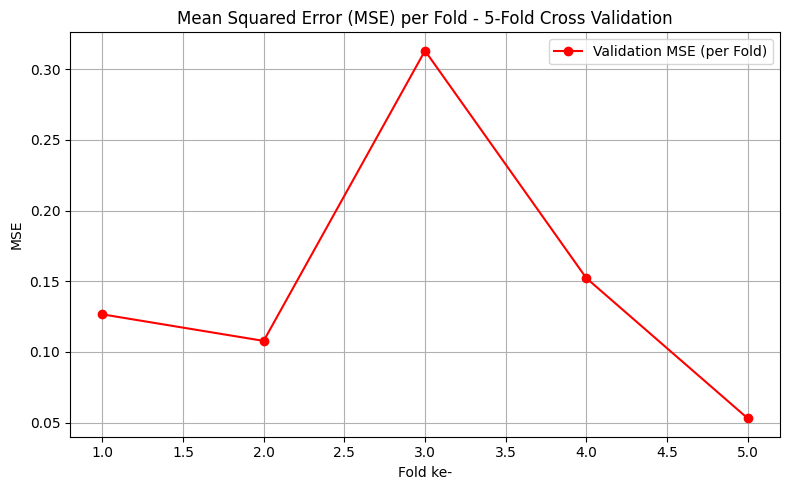

Rata-rata MSE: 0.15053340926034753


In [ ]:
# Visualisasi Validation MSE per Fold
plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), mse_list, marker='o', color='red', label='Validation MSE (per Fold)')
plt.title('Mean Squared Error (MSE) per Fold - 5-Fold Cross Validation')
plt.xlabel('Fold ke-')
plt.ylabel('MSE')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("Rata-rata MSE:", np.mean(mse_list))

In [ ]:
# Evaluasi MSE model akhir terhadap seluruh data
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X, verbose=0)
mse = mean_squared_error(y, y_pred)
print(f"MSE Model Akhir: {mse:.4f}")

MSE Model Akhir: 0.1330


In [ ]:
import pandas as pd

# Input nilai Brix baru sebagai DataFrame (dengan nama kolom yang sesuai)
nilai_brix_baru = pd.DataFrame({'Nilai brix': [75]})
nilai_brix_norm = scaler_x.transform(nilai_brix_baru)

# Prediksi
prediksi_norm = model.predict(nilai_brix_norm)
prediksi_asli = scaler_y.inverse_transform(prediksi_norm)

print(f"Prediksi Gula Pereduksi untuk Brix 75: {prediksi_asli[0][0]:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Prediksi Gula Pereduksi untuk Brix 75: 49.75%
